In [1]:
from google.colab import drive
import zipfile, os

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Dataset extracted to:", BASE)

print("\nBASE folders:")
print(os.listdir(BASE))


Mounted at /content/drive
Dataset extracted to: /content/dataset/Parkinson's Dataset Final

BASE folders:
['Hand Pd', 'New hand pd Dataset']


In [2]:
HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
NEWHANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")

print("HANDPD_ROOT:", HANDPD_ROOT)
print("NEWHANDPD_ROOT:", NEWHANDPD_ROOT)

print("\nInside Hand Pd:", os.listdir(HANDPD_ROOT))
print("Inside New hand pd Dataset:", os.listdir(NEWHANDPD_ROOT))

print("\nInside Spiral_HandPD:", os.listdir(os.path.join(HANDPD_ROOT, "Spiral_HandPD")))
print("Inside Meander_HandPD:", os.listdir(os.path.join(HANDPD_ROOT, "Meander_HandPD")))


HANDPD_ROOT: /content/dataset/Parkinson's Dataset Final/Hand Pd
NEWHANDPD_ROOT: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset

Inside Hand Pd: ['Meander_HandPD', 'Spiral_HandPD']
Inside New hand pd Dataset: ['Healthy', "Parkinson's"]

Inside Spiral_HandPD: ['parkinson', 'healthy']
Inside Meander_HandPD: ['parkinson', 'healthy']


In [3]:
import cv2
import numpy as np

IMG_SIZE = 224

X = []
y = []

def load_images(folder, label):
    count = 0
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(label)
        count += 1

    return count


In [4]:
total_handpd = 0

for sub in ["Spiral_HandPD", "Meander_HandPD"]:
    healthy_path = os.path.join(HANDPD_ROOT, sub, "healthy")
    park_path = os.path.join(HANDPD_ROOT, sub, "parkinson")

    total_handpd += load_images(healthy_path, 0)
    total_handpd += load_images(park_path, 1)

print("HandPD loaded images:", total_handpd)


HandPD loaded images: 808


In [7]:
total_newhandpd = 0

healthy_path = os.path.join(NEWHANDPD_ROOT, "Healthy")
park_path = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

total_newhandpd += load_images(healthy_path, 0)
total_newhandpd += load_images(park_path, 1)

print("NewHandPD loaded images:", total_newhandpd)


NewHandPD loaded images: 0


In [8]:
import os

print("Inside New hand pd Dataset:")
print(os.listdir(NEWHANDPD_ROOT))

for folder in os.listdir(NEWHANDPD_ROOT):
    full_path = os.path.join(NEWHANDPD_ROOT, folder)
    print("\nFolder:", folder)
    print("Path:", full_path)

    if os.path.isdir(full_path):
        print("Contains:", os.listdir(full_path)[:20])


Inside New hand pd Dataset:
['Healthy', "Parkinson's"]

Folder: Healthy
Path: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Healthy
Contains: ['HealthyCircle', 'HealthyMeander', 'HealthySpiral', 'HealthySignal']

Folder: Parkinson's
Path: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Parkinson's
Contains: ['PatientSpiral', 'PatientSignal', 'PatientCircle', 'PatientMeander']


In [9]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

def load_images_recursive(root_folder, label, X, y):
    total = 0
    for sub in os.listdir(root_folder):
        sub_path = os.path.join(root_folder, sub)

        if not os.path.isdir(sub_path):
            continue

        for img_name in os.listdir(sub_path):
            img_path = os.path.join(sub_path, img_name)

            # Only images
            if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            X.append(img)
            y.append(label)
            total += 1

    return total


In [10]:
X, y = [], []

# ---- HandPD already loaded earlier (keep it) ----
# Now load NewHandPD correctly:

healthy_root = os.path.join(NEWHANDPD_ROOT, "Healthy")
park_root    = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

total_newhandpd = 0
total_newhandpd += load_images_recursive(healthy_root, 0, X, y)
total_newhandpd += load_images_recursive(park_root, 1, X, y)

print("NewHandPD loaded images:", total_newhandpd)
print("Total merged images so far:", len(X))


NewHandPD loaded images: 0
Total merged images so far: 0


In [11]:
import os

healthy_root = os.path.join(NEWHANDPD_ROOT, "Healthy")
park_root    = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

print("Healthy subfolders:", os.listdir(healthy_root))
print("Parkinson subfolders:", os.listdir(park_root))

# check inside one folder
sample_folder = os.path.join(healthy_root, os.listdir(healthy_root)[0])
print("\nSample folder:", sample_folder)
print("Files inside:", os.listdir(sample_folder)[:10])


Healthy subfolders: ['HealthyCircle', 'HealthyMeander', 'HealthySpiral', 'HealthySignal']
Parkinson subfolders: ['PatientSpiral', 'PatientSignal', 'PatientCircle', 'PatientMeander']

Sample folder: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Healthy/HealthyCircle
Files inside: ['Circle']


In [12]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

def load_images_recursive(root_folder, label, X, y):
    total = 0

    for root, dirs, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                img_path = os.path.join(root, file)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                X.append(img)
                y.append(label)
                total += 1

    return total


In [14]:
X, y = [], []


for subfolder in ["Spiral_HandPD", "Meander_HandPD"]:
    base_sub = os.path.join(HANDPD_ROOT, subfolder)

    healthy_path = os.path.join(base_sub, "healthy")
    park_path    = os.path.join(base_sub, "parkinson")

    load_images_recursive(healthy_path, 0, X, y)
    load_images_recursive(park_path, 1, X, y)

print("HandPD loaded:", len(X))

healthy_root = os.path.join(NEWHANDPD_ROOT, "Healthy")
park_root    = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

load_images_recursive(healthy_root, 0, X, y)
load_images_recursive(park_root, 1, X, y)

print("Total merged images:", len(X))


HandPD loaded: 808
Total merged images: 1320


In [15]:
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype("float32")
y = np.array(y).astype("int32")

print("Final X shape:", X.shape)
print("Healthy:", np.sum(y==0))
print("Parkinson:", np.sum(y==1))


Final X shape: (1320, 224, 224, 1)
Healthy: 449
Parkinson: 871


In [16]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False
)

datagen.fit(X_train)


Train: (990, 224, 224, 1) Test: (330, 224, 224, 1)


In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weights_dict)


Class weights: {np.int32(0): np.float64(1.4688427299703264), np.int32(1): np.float64(0.7580398162327718)}


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")

    def call(self, x):
        x = self.proj(x)  # (B, H/patch, W/patch, embed_dim)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])  # (B, num_patches, embed_dim)
        return x


class PositionalEncoding(layers.Layer):
    def __init__(self, num_patches, dim):
        super().__init__()
        self.num_patches = num_patches
        self.dim = dim

        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, num_patches, dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.pos_embedding


class TransformerBlock(layers.Layer):
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        attn_out = self.attn(self.norm1(x), self.norm1(x))
        x = x + self.drop1(attn_out, training=training)

        mlp_out = self.mlp(self.norm2(x), training=training)
        x = x + mlp_out
        return x


def build_custom_vit_feature_extractor(
    input_shape=(224, 224, 1),
    patch_size=16,
    dropout=0.15
):
    inputs = layers.Input(shape=input_shape)

    x = PatchEmbedding(patch_size=patch_size, embed_dim=526)(inputs)

    x = PositionalEncoding(num_patches=196, dim=526)(x)

    x = TransformerBlock(dim=526, num_heads=2, mlp_dim=1024, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(256)(x)
    x = TransformerBlock(dim=256, num_heads=2, mlp_dim=512, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(128)(x)
    x = TransformerBlock(dim=128, num_heads=2, mlp_dim=256, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(64, name="stage64_features")(x)
    x = TransformerBlock(dim=64, num_heads=2, mlp_dim=128, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(32)(x)
    x = TransformerBlock(dim=32, num_heads=2, mlp_dim=64, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(16)(x)
    x = TransformerBlock(dim=16, num_heads=2, mlp_dim=32, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(8)(x)
    x = TransformerBlock(dim=8, num_heads=2, mlp_dim=16, dropout=dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(4, name="final_4dim_features")(x)
    x = TransformerBlock(dim=4, num_heads=1, mlp_dim=8, dropout=dropout)(x)

    features = layers.GlobalAveragePooling1D(name="vit_final_feature")(x)

    return Model(inputs, features, name="Custom_ViT_Feature_Extractor")


vit_extractor = build_custom_vit_feature_extractor()
vit_extractor.summary()


Model: "Custom_ViT_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 196, 526)       │     3,297,992 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 256)       │       790,016 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 128)       │       198,400 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 196, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage64_features (Dense)        │ (None, 196, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 64)        │        50,048 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_11          │ (None, 196, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 196, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 32)        │        12,736 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 196, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 16)        │         3,29

 Total params: 4,772,722 (18.21 MB)

 Trainable params: 4,772,722 (18.21 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras import Model, layers

probe_input = vit_extractor.input
probe_features = vit_extractor.output

probe_output = layers.Dense(1, activation="sigmoid", name="probe_output")(probe_features)

probe_model = Model(probe_input, probe_output, name="MiniViT_Probe_Model")

probe_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

probe_model.summary()


Model: "MiniViT_Probe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 196, 526)       │     3,297,992 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 256)       │       790,016 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 128)       │       198,400 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 196, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage64_features (Dense)        │ (None, 196, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 64)        │        50,048 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_11          │ (None, 196, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 196, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 32)        │        12,736 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 196, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 16)        │         3,29

 Total params: 4,772,727 (18.21 MB)

 Trainable params: 4,772,727 (18.21 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "BEST_MINIVIT_PROBE.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [21]:
history_probe = probe_model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.5184 - loss: 0.8711
Epoch 1: val_loss improved from inf to 0.68031, saving model to BEST_MINIVIT_PROBE.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5180 - loss: 0.8694 - val_accuracy: 0.6606 - val_loss: 0.6803 - learning_rate: 1.0000e-04
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4605 - loss: 0.7088
Epoch 2: val_loss did not improve from 0.68031
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.4607 - loss: 0.7087 - val_accuracy: 0.3394 - val_loss: 0.7685 - learning_rate: 1.0000e-04
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4278 - loss: 0.7007
Epoch 3: val_loss did not improve from 0.68031
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.4286 - loss: 0.7006 - val_accuracy: 0.3394 - val_loss: 0.6969 - learning_rate: 1.0000e-04
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5450 - loss: 0.6955
Epoch 4: val_loss did not improve from 0.68031

Epoch 

In [22]:
import tensorflow as tf
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))

Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [23]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [24]:
import numpy as np

print("Train Healthy:", np.sum(y_train==0))
print("Train Parkinson:", np.sum(y_train==1))

print("Test Healthy:", np.sum(y_test==0))
print("Test Parkinson:", np.sum(y_test==1))


Train Healthy: 337
Train Parkinson: 653
Test Healthy: 112
Test Parkinson: 218


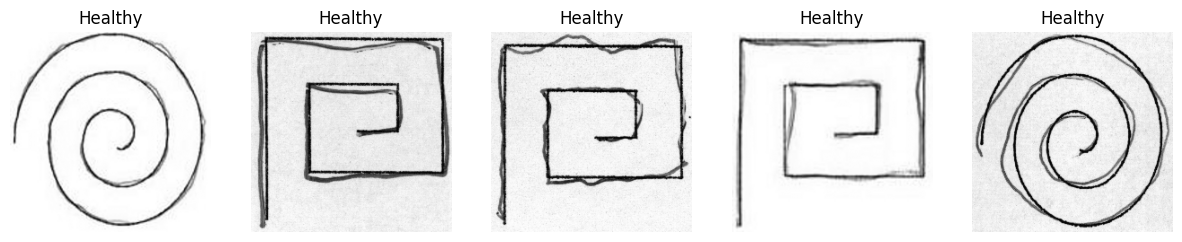

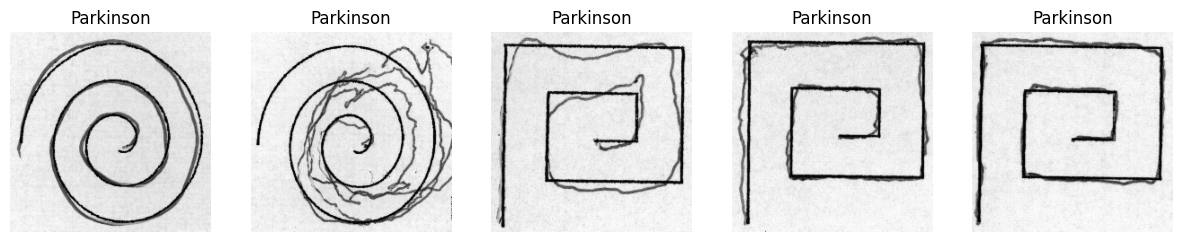

In [25]:
import matplotlib.pyplot as plt

def show_samples(X, y, label_value, n=5):
    idx = np.where(y == label_value)[0][:n]
    plt.figure(figsize=(15, 3))
    for i, j in enumerate(idx):
        plt.subplot(1, n, i+1)
        plt.imshow(X[j].squeeze(), cmap="gray")
        plt.title("Healthy" if label_value==0 else "Parkinson")
        plt.axis("off")
    plt.show()

show_samples(X_train, y_train, 0, n=5)
show_samples(X_train, y_train, 1, n=5)


In [26]:
history_test = probe_model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=5,
    verbose=1
)


Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 95s 723ms/step - accuracy: 0.6814 - loss: 0.6485 - val_accuracy: 0.6606 - val_loss: 0.6475
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 64s 99ms/step - accuracy: 0.6562 - loss: 0.6458 - val_accuracy: 0.6606 - val_loss: 0.6405
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6397 - loss: 0.6600 - val_accuracy: 0.6606 - val_loss: 0.6405
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.6674 - loss: 0.6370 - val_accuracy: 0.6606 - val_loss: 0.6439
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.6732 - loss: 0.6375 - val_accuracy: 0.6606 - val_loss: 0.6453


In [27]:
feat64_model = tf.keras.Model(
    inputs=vit_extractor.input,
    outputs=vit_extractor.get_layer("transformer_block_3").output,
    name="feat64_model"
)

X_train_feat64 = feat64_model.predict(X_train, batch_size=16, verbose=1)
X_test_feat64  = feat64_model.predict(X_test, batch_size=16, verbose=1)

print(X_train_feat64.shape, X_test_feat64.shape)


62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step
(990, 196, 64) (330, 196, 64)


In [28]:
X_train_feat64 = np.mean(X_train_feat64, axis=1)
X_test_feat64  = np.mean(X_test_feat64, axis=1)

print(X_train_feat64.shape, X_test_feat64.shape)


(990, 64) (330, 64)


In [29]:
fcnn_64 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

fcnn_64.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fcnn64 = fcnn_64.fit(
    X_train_feat64, y_train,
    validation_data=(X_test_feat64, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.4909 - loss: 1.0514 - val_accuracy: 0.6606 - val_loss: 0.6416
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6322 - loss: 0.6820 - val_accuracy: 0.6606 - val_loss: 0.6415
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6391 - loss: 0.6611 - val_accuracy: 0.6606 - val_loss: 0.6539
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6565 - loss: 0.6440 - val_accuracy: 0.6606 - val_loss: 0.6441
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6506 - loss: 0.6508 - val_accuracy: 0.6606 - val_loss: 0.6440
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6416 - val_accuracy: 0.6606 - val_loss: 0.6441
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6619 - loss: 0.6416 - val_accuracy: 0.6606 - val_loss: 0.6412
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6424 - loss: 0.6657 - val_accuracy: 0.6606 - val_los

In [30]:
print("Train feat shape:", X_train_feat64.shape)
print("Test feat shape:", X_test_feat64.shape)
print("Example feature row:", X_train_feat64[0][:10])


Train feat shape: (990, 64)
Test feat shape: (330, 64)
Example feature row: [-0.74111587 -1.0780244  -0.42364848  2.3654132   2.4874227  -2.2181435
  0.49665314  0.1061843   1.584593   -3.3746305 ]


In [31]:
print("Feature variance:", np.var(X_train_feat64))


Feature variance: 3.208385


In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.4688427299703264), 1: np.float64(0.7580398162327718)}


In [33]:
history_fcnn64 = fcnn_64.fit(
    X_train_feat64, y_train,
    validation_data=(X_test_feat64, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6524 - loss: 0.7312 - val_accuracy: 0.6606 - val_loss: 0.6902
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4890 - loss: 0.6955 - val_accuracy: 0.6606 - val_loss: 0.6823
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4974 - loss: 0.7100 - val_accuracy: 0.6606 - val_loss: 0.6880
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5968 - loss: 0.6807 - val_accuracy: 0.6606 - val_loss: 0.6770
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5951 - loss: 0.6896 - val_accuracy: 0.6606 - val_loss: 0.6908
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4281 - loss: 0.7033 - val_accuracy: 0.6606 - val_loss: 0.6921
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4734 - loss: 0.6964 - val_accuracy: 0.6606 - val_loss: 0.6920
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4922 - loss: 0.6913 - val_accuracy: 0.6606 - val_loss